In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
Device name: Tesla T4


In [2]:
import torch

x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print(x)
print(x.shape)
print(x.dtype)

# Move it to GPU
x_gpu = x.to("cuda")
print(x_gpu.device)

tensor([[1., 2.],
        [3., 4.]])
torch.Size([2, 2])
torch.float32
cuda:0


In [4]:
w = torch.tensor(2.0, requires_grad=True)
x = torch.tensor(3.0)

y = w * x
y.backward()

print(w.grad)

tensor(3.)


In [5]:
import torch.nn as nn

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(10, 5)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(5, 1)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

model = SimpleNet()
print(model)

# Test it with a random input
sample_input = torch.randn(1, 10)
output = model(sample_input)
print(output)

SimpleNet(
  (layer1): Linear(in_features=10, out_features=5, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)
tensor([[-0.0743]], grad_fn=<AddmmBackward0>)


100%|██████████| 170M/170M [33:36<00:00, 84.6kB/s]


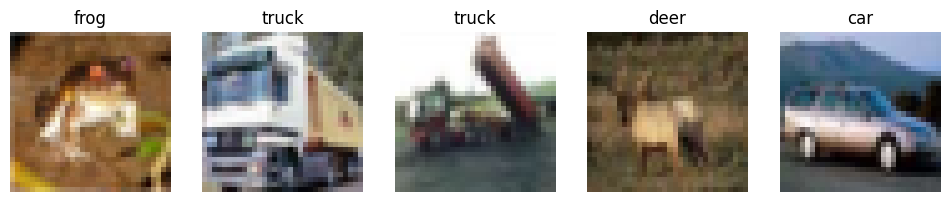

In [6]:
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Transform: convert images to tensors and normalize pixel values
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Download CIFAR-10
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Visualize a few images
def imshow(img):
    img = img / 2 + 0.5
    plt.imshow(img.permute(1, 2, 0))
    plt.axis('off')

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    img, label = trainset[i]
    plt.sca(axes[i])
    imshow(img)
    axes[i].set_title(classes[label])
plt.show()

In [8]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)


        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN().to("cuda")
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [9]:
from torch.utils.data import DataLoader
import torch.optim as optim

# Load train and test sets
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

train_losses = []
train_accuracies = []

num_epochs = 8
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in trainloader:
        images, labels = images.to("cuda"), labels.to("cuda")

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(trainloader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.2f}%")

Epoch 1/8 - Loss: 1.6017 - Accuracy: 42.05%
Epoch 2/8 - Loss: 1.1526 - Accuracy: 59.17%
Epoch 3/8 - Loss: 0.9667 - Accuracy: 65.84%
Epoch 4/8 - Loss: 0.8387 - Accuracy: 70.54%
Epoch 5/8 - Loss: 0.7289 - Accuracy: 74.37%
Epoch 6/8 - Loss: 0.6393 - Accuracy: 77.44%
Epoch 7/8 - Loss: 0.5537 - Accuracy: 80.55%
Epoch 8/8 - Loss: 0.4707 - Accuracy: 83.36%


In [10]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to("cuda"), labels.to("cuda")
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 69.81%


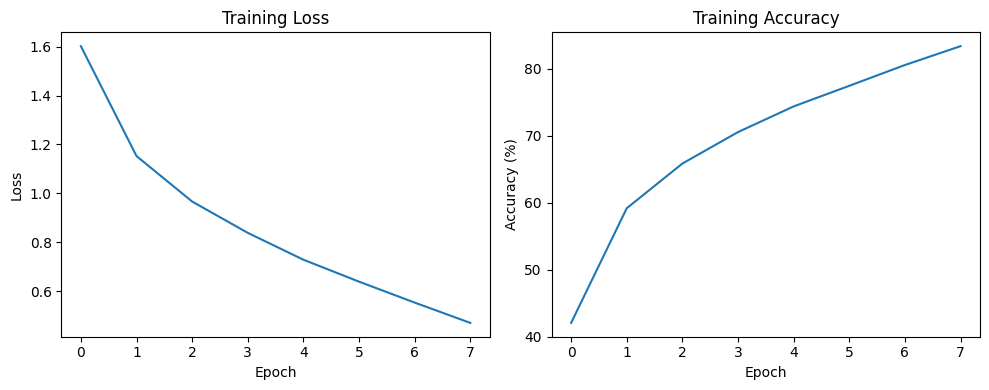

In [11]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

In [12]:
import torchvision.models as models

# Load ResNet18 pretrained on ImageNet
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all existing layers
for param in resnet.parameters():
    param.requires_grad = False

# Replace the final classification layer: ResNet18 originally outputs 1000 classes (ImageNet),
# we need 10 (CIFAR-10)
resnet.fc = nn.Linear(resnet.fc.in_features, 10)

resnet = resnet.to("cuda")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


In [13]:
transform_resnet = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet stats
])

trainset_resnet = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_resnet)
testset_resnet = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_resnet)

trainloader_resnet = DataLoader(trainset_resnet, batch_size=32, shuffle=True)
testloader_resnet = DataLoader(testset_resnet, batch_size=32, shuffle=False)

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.fc.parameters(), lr=0.001)   # only optimizing the new final layer

num_epochs = 3   # transfer learning needs far fewer epochs
for epoch in range(num_epochs):
    resnet.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in trainloader_resnet:
        images, labels = images.to("cuda"), labels.to("cuda")

        optimizer.zero_grad()
        outputs = resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss/len(trainloader_resnet):.4f} - Accuracy: {100*correct/total:.2f}%")

Epoch 1/3 - Loss: 0.8052 - Accuracy: 73.13%
Epoch 2/3 - Loss: 0.6420 - Accuracy: 77.63%
Epoch 3/3 - Loss: 0.6175 - Accuracy: 78.67%


In [15]:
resnet.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader_resnet:
        images, labels = images.to("cuda"), labels.to("cuda")
        outputs = resnet(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"ResNet18 Transfer Learning Test Accuracy: {100 * correct / total:.2f}%")

ResNet18 Transfer Learning Test Accuracy: 80.30%


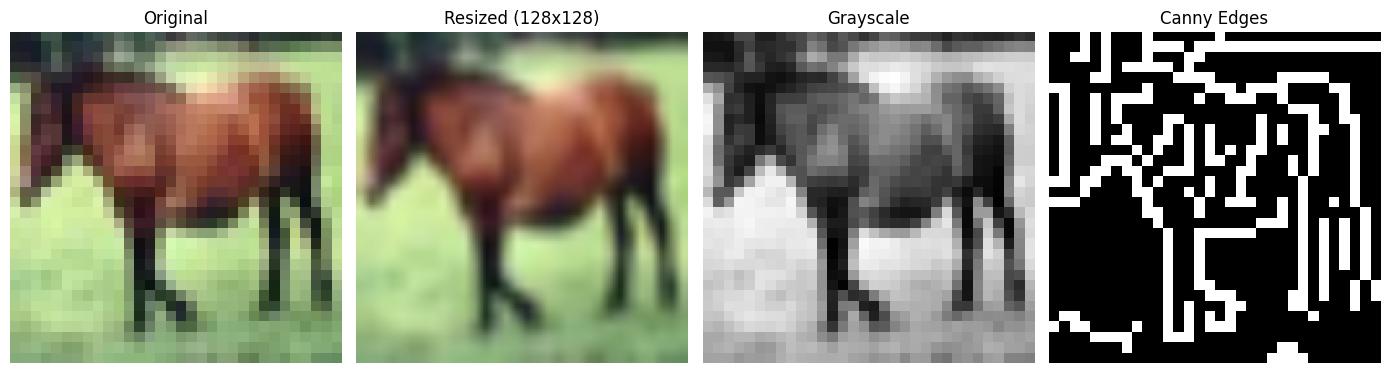

Original class: horse
Number of edge pixels detected: 281


In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Grab one sample image from CIFAR-10 and convert it for OpenCV use
img_tensor, label = trainset[7]
img_np = img_tensor.permute(1, 2, 0).numpy()
img_np = ((img_np / 2 + 0.5) * 255).astype(np.uint8)   # un-normalize and convert to 0-255 range

# 1. Resize
resized = cv2.resize(img_np, (128, 128))

# 2. Convert to grayscale
gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

# 3. Edge detection (Canny)
edges = cv2.Canny(gray, threshold1=100, threshold2=200)

# Display all four versions side by side
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(img_np); axes[0].set_title("Original"); axes[0].axis('off')
axes[1].imshow(resized); axes[1].set_title("Resized (128x128)"); axes[1].axis('off')
axes[2].imshow(gray, cmap='gray'); axes[2].set_title("Grayscale"); axes[2].axis('off')
axes[3].imshow(edges, cmap='gray'); axes[3].set_title("Canny Edges"); axes[3].axis('off')
plt.tight_layout()
plt.savefig("opencv_demo.png")
plt.show()

print(f"Original class: {classes[label]}")
print(f"Number of edge pixels detected: {np.sum(edges > 0)}")

In [17]:
augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')